# Direct Logit Attribution (DLA)

**Core question:** for each layer, how much does the *attention output* and the *FFN output*
shift the class logits? Are middle layers load-bearing for the prediction even when their
update norm is tiny?

**Method**
- Decompose the residual stream into additive components: `embeddings + sum_l (attn_l + ffn_l) = h_L`.
- Push each component (at the classifier token(s)) through the final LayerNorm + classifier head,
  **freezing the LayerNorm mean/scale from the real final activation `h_L`**. Because centering is
  linear and the scale is frozen, the per-component logit contributions sum *exactly* to the model
  logits (verified each run) — this is the standard logit-lens / DLA decomposition.
- Report each component's contribution to the ground-truth class and predicted class, the norm of
  its logit-contribution vector, plus a **logit-lens accuracy** curve ("if we stopped at layer l").

Read-out heads: `classifier(CLS)` for the plain models, and the averaged
`cls_classifier(CLS)`, `distillation_classifier(DIST)` for the distilled-with-teacher models.


In [1]:
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Dict, List, Optional, Sequence
import gc

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import load_dataset
from tqdm.auto import tqdm
from transformers import (
    AutoImageProcessor,
    DeiTForImageClassificationWithTeacher,
    ViTForImageClassification,
)

sns.set_theme(style="whitegrid")


def choose_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


device = choose_device()
print(f"Using device: {device}")


@dataclass(frozen=True)
class ModelSpec:
    name: str
    repo_id: str
    imagenet_top1: float
    imagenet_top5: float
    params: str
    is_distilled: bool = False


MODEL_SPECS: List[ModelSpec] = [
    ModelSpec("DeiT-tiny", "facebook/deit-tiny-patch16-224", 72.2, 91.1, "5M"),
    ModelSpec("DeiT-small", "facebook/deit-small-patch16-224", 79.9, 95.0, "22M"),
    ModelSpec("DeiT-base", "facebook/deit-base-patch16-224", 81.8, 95.6, "86M"),
    ModelSpec("DeiT-tiny distilled", "facebook/deit-tiny-distilled-patch16-224", 74.5, 91.9, "6M", True),
    ModelSpec("DeiT-small distilled", "facebook/deit-small-distilled-patch16-224", 81.2, 95.4, "22M", True),
    ModelSpec("DeiT-base distilled", "facebook/deit-base-distilled-patch16-224", 83.4, 96.5, "87M", True),
    ModelSpec("DeiT-base 384", "facebook/deit-base-patch16-384", 82.9, 96.2, "87M"),
    ModelSpec("DeiT-base distilled 384", "facebook/deit-base-distilled-patch16-384", 85.2, 97.2, "88M", True),
]


Using device: cuda


In [2]:
def slugify(value: str) -> str:
    return value.lower().replace("-", "_").replace(" ", "_")


def select_model_specs(selected_names: Optional[Sequence[str]] = None) -> List[ModelSpec]:
    if not selected_names:
        return MODEL_SPECS
    selected_name_set = set(selected_names)
    selected = [spec for spec in MODEL_SPECS if spec.name in selected_name_set]
    missing = sorted(selected_name_set - {spec.name for spec in selected})
    if missing:
        raise ValueError(f"Unknown model names: {missing}")
    return selected


def get_model_class(spec: ModelSpec):
    if spec.is_distilled:
        return DeiTForImageClassificationWithTeacher
    return ViTForImageClassification


def get_base_model(model):
    prefix = getattr(model, "base_model_prefix", None)
    if prefix and hasattr(model, prefix):
        return getattr(model, prefix)
    for attr in ("deit", "vit", "model"):
        if hasattr(model, attr):
            return getattr(model, attr)
    return model


def get_layer_stack(model):
    base = get_base_model(model)
    encoder = getattr(base, "encoder", None)
    if encoder is not None:
        if hasattr(encoder, "layer"):
            return encoder.layer
        if hasattr(encoder, "layers"):
            return encoder.layers
    # Version-robust fallback: the largest ModuleList of repeated transformer blocks.
    best = None
    for _, module in model.named_modules():
        if isinstance(module, torch.nn.ModuleList) and len(module) >= 2:
            if best is None or len(module) > len(best):
                best = module
    if best is None:
        raise AttributeError("Could not locate the transformer block list.")
    return best


def cleanup_model(*objects) -> None:
    for obj in objects:
        del obj
    if device.type == "cuda":
        torch.cuda.empty_cache()
    gc.collect()


def load_model_and_processor(spec: ModelSpec):
    processor = AutoImageProcessor.from_pretrained(spec.repo_id, use_fast=True)
    model_cls = get_model_class(spec)
    model = model_cls.from_pretrained(spec.repo_id, attn_implementation="eager")
    model = model.to(device).eval()
    return model, processor


def get_final_layernorm(model):
    base = get_base_model(model)
    for attr in ("layernorm", "layer_norm", "norm", "ln_post"):
        if hasattr(base, attr):
            return getattr(base, attr)
    raise AttributeError("Could not locate the final layernorm.")


def get_readout_heads(model):
    """Return [(token_index, classifier_module, head_weight), ...] matching how logits are formed."""
    if hasattr(model, "cls_classifier") and hasattr(model, "distillation_classifier"):
        return [(0, model.cls_classifier, 0.5), (1, model.distillation_classifier, 0.5)]
    if hasattr(model, "classifier"):
        return [(0, model.classifier, 1.0)]
    raise AttributeError("Could not locate a classifier head on the model.")


def get_attention_module(block):
    """Find the sub-module whose output is the attention contribution added to the residual."""
    for name, child in block.named_children():
        lname = name.lower()
        if "attention" in lname or "attn" in lname:
            return child
    raise AttributeError("Could not locate the attention submodule in a transformer block.")


In [3]:
DLA_METRICS = ["dla_label", "dla_pred", "contrib_norm", "comp_norm"]


@torch.inference_mode()
def run_residual_decomposition(model, inputs: Dict):
    """Return the additive residual components without depending on internal submodule names.

    Uses `output_hidden_states` for the residual stream (h_0 .. h_L) and a forward hook on each
    block's attention submodule to capture the attention contribution a_l. Because the block computes
    h_{l+1} = h_l + a_l + f_l, the FFN contribution is recovered as f_l = (h_{l+1} - h_l) - a_l.
    """
    layer_stack = get_layer_stack(model)
    attention_store: Dict[int, torch.Tensor] = {}
    handles = []

    def make_attention_hook(layer_idx: int):
        def hook(module, module_inputs, module_output):
            attention_store[layer_idx] = module_output[0] if isinstance(module_output, (tuple, list)) else module_output
        return hook

    for layer_idx, block in enumerate(layer_stack):
        handles.append(get_attention_module(block).register_forward_hook(make_attention_hook(layer_idx)))

    try:
        outputs = model(**inputs, output_hidden_states=True)
    finally:
        for handle in handles:
            handle.remove()

    if outputs.hidden_states is None:
        raise ValueError("Model did not return hidden states; cannot decompose the residual stream.")

    residual_states = list(outputs.hidden_states)  # h_0 (embeddings) .. h_L (pre final-LN)
    num_layers = len(layer_stack)
    attention_outputs = [attention_store[i] for i in range(num_layers)]
    ffn_outputs = [
        residual_states[i + 1] - residual_states[i] - attention_outputs[i] for i in range(num_layers)
    ]
    return attention_outputs, ffn_outputs, residual_states


def frozen_ln_vector(component_token: torch.Tensor, final_token: torch.Tensor, final_layernorm) -> torch.Tensor:
    """Apply the final LayerNorm to `component_token` with mean/scale frozen from `final_token`.
    Returns the post-LN vector excluding the additive bias (beta)."""
    eps = final_layernorm.eps
    gamma = final_layernorm.weight
    std = torch.sqrt(final_token.var(dim=-1, unbiased=False, keepdim=True) + eps)
    centered = component_token - component_token.mean(dim=-1, keepdim=True)
    return gamma * centered / std


def component_logit_contribution(component, residual_states, final_layernorm, heads) -> torch.Tensor:
    """Logit contribution (batch, num_classes) of one additive component, summed over read-out heads."""
    final_hidden = residual_states[-1]
    total = None
    for token_idx, classifier, head_weight in heads:
        frozen = frozen_ln_vector(component[:, token_idx, :], final_hidden[:, token_idx, :], final_layernorm)
        logits = frozen @ classifier.weight.t()
        total = head_weight * logits if total is None else total + head_weight * logits
    return total


def logit_lens_logits(residual_state, final_layernorm, heads) -> torch.Tensor:
    """Real read-out (full LayerNorm) applied to an intermediate residual state -> 'stop here' logits."""
    total = None
    for token_idx, classifier, head_weight in heads:
        logits = classifier(final_layernorm(residual_state[:, token_idx, :]))
        total = head_weight * logits if total is None else total + head_weight * logits
    return total


def readout_constant(final_layernorm, heads) -> torch.Tensor:
    """The component-independent part of the logits: classifier(beta) + classifier bias."""
    beta = final_layernorm.bias
    total = None
    for token_idx, classifier, head_weight in heads:
        const = classifier(beta)
        total = head_weight * const if total is None else total + head_weight * const
    return total


@torch.inference_mode()
def collect_dla_records(model, processor, dataset_split, max_samples, batch_size, show_progress=True):
    final_layernorm = get_final_layernorm(model)
    heads = get_readout_heads(model)
    const = readout_constant(final_layernorm, heads)
    num_layers = len(get_layer_stack(model))
    cls_token = heads[0][0]

    records: List[Dict] = []
    lens_records: List[Dict] = []
    verified = False

    total_samples = min(max_samples, len(dataset_split))
    iterator = range(0, total_samples, batch_size)
    if show_progress:
        iterator = tqdm(iterator, desc="Computing DLA", leave=False)

    for start_idx in iterator:
        batch = dataset_split[start_idx : start_idx + batch_size]
        images = [image.convert("RGB") for image in batch["image"]]
        labels = list(batch["label"])
        inputs = processor(images=images, return_tensors="pt")
        inputs = {key: value.to(device) for key, value in inputs.items()}

        attn_outs, ffn_outs, residual_states = run_residual_decomposition(model, inputs)

        model_logits = logit_lens_logits(residual_states[-1], final_layernorm, heads)
        predictions = model_logits.argmax(dim=-1)

        attn_contribs = [component_logit_contribution(a, residual_states, final_layernorm, heads) for a in attn_outs]
        ffn_contribs = [component_logit_contribution(f, residual_states, final_layernorm, heads) for f in ffn_outs]
        attn_norms = [a[:, cls_token, :].norm(dim=-1) for a in attn_outs]
        ffn_norms = [f[:, cls_token, :].norm(dim=-1) for f in ffn_outs]

        if not verified:
            emb_contrib = component_logit_contribution(residual_states[0], residual_states, final_layernorm, heads)
            recon = const.unsqueeze(0) + emb_contrib + sum(attn_contribs) + sum(ffn_contribs)
            real_logits = model(**inputs).logits
            lens_gap = (model_logits - real_logits).abs().max().item()
            recon_gap = (recon - real_logits).abs().max().item()
            print(f"  [sanity] max|logit_lens - model| = {lens_gap:.3e} | max|DLA_sum - model| = {recon_gap:.3e}")
            verified = True

        batch_size_actual = len(labels)
        for local_idx in range(batch_size_actual):
            label = int(labels[local_idx])
            prediction = int(predictions[local_idx].item())
            is_correct = prediction == label
            for component_name, contribs, norms in (
                ("attention", attn_contribs, attn_norms),
                ("ffn", ffn_contribs, ffn_norms),
            ):
                for layer_idx in range(num_layers):
                    vec = contribs[layer_idx][local_idx]
                    centered = vec - vec.mean()
                    records.append({
                        "sample_index": start_idx + local_idx,
                        "layer": layer_idx,
                        "component": component_name,
                        "label": label,
                        "prediction": prediction,
                        "is_correct": is_correct,
                        "dla_label": float(vec[label].item()),
                        "dla_pred": float(vec[prediction].item()),
                        "contrib_norm": float(centered.norm().item()),
                        "comp_norm": float(norms[layer_idx][local_idx].item()),
                    })

        for lens_layer, state in enumerate(residual_states):
            lens_logits = logit_lens_logits(state, final_layernorm, heads)
            lens_pred = lens_logits.argmax(dim=-1)
            for local_idx in range(batch_size_actual):
                lens_records.append({
                    "sample_index": start_idx + local_idx,
                    "lens_layer": lens_layer,
                    "label": int(labels[local_idx]),
                    "lens_prediction": int(lens_pred[local_idx].item()),
                    "is_correct": int(lens_pred[local_idx].item()) == int(labels[local_idx]),
                })

        del inputs, attn_outs, ffn_outs, residual_states, attn_contribs, ffn_contribs
        if device.type == "cuda":
            torch.cuda.empty_cache()

    return pd.DataFrame(records), pd.DataFrame(lens_records)


def aggregate_dla_records(records_df: pd.DataFrame) -> pd.DataFrame:
    summaries = []
    splits = {
        "all": records_df,
        "correct": records_df[records_df["is_correct"]],
        "incorrect": records_df[~records_df["is_correct"]],
    }
    for split_name, split_df in splits.items():
        if split_df.empty:
            continue
        melted = split_df.melt(
            id_vars=["layer", "component"], value_vars=DLA_METRICS, var_name="metric", value_name="value"
        )
        summary = melted.groupby(["layer", "component", "metric"], as_index=False).agg(
            mean=("value", "mean"), std=("value", "std"), count=("value", "size")
        )
        summary["split"] = split_name
        summaries.append(summary)
    return pd.concat(summaries, ignore_index=True)


def aggregate_lens_records(lens_df: pd.DataFrame) -> pd.DataFrame:
    return lens_df.groupby("lens_layer", as_index=False).agg(
        accuracy=("is_correct", lambda values: round(100.0 * values.mean(), 2)),
        count=("is_correct", "size"),
    )


In [4]:
def run_dla_suite(model_specs: Sequence[ModelSpec], dataset_split, config: Dict):
    results_dir = Path(config["results_dir"])
    results_dir.mkdir(parents=True, exist_ok=True)

    summary_frames, lens_frames = [], []
    for spec in model_specs:
        batch_size = config["batch_size_384"] if "384" in spec.repo_id else config["batch_size"]
        print(f"Running DLA for {spec.name} with batch_size={batch_size}...")
        model, processor = load_model_and_processor(spec)
        raw_df, lens_raw_df = collect_dla_records(
            model, processor, dataset_split,
            max_samples=config["max_samples"], batch_size=batch_size,
            show_progress=config["show_progress"],
        )

        summary_df = aggregate_dla_records(raw_df)
        summary_df.insert(0, "repo_id", spec.repo_id)
        summary_df.insert(0, "model_name", spec.name)

        lens_df = aggregate_lens_records(lens_raw_df)
        lens_df.insert(0, "repo_id", spec.repo_id)
        lens_df.insert(0, "model_name", spec.name)

        summary_df.to_csv(results_dir / f"{slugify(spec.name)}_dla_summary.csv", index=False)
        lens_df.to_csv(results_dir / f"{slugify(spec.name)}_logit_lens.csv", index=False)
        summary_frames.append(summary_df)
        lens_frames.append(lens_df)
        cleanup_model(model, processor)

    summary_all = pd.concat(summary_frames, ignore_index=True)
    lens_all = pd.concat(lens_frames, ignore_index=True)
    summary_all.to_csv(results_dir / "dla_summary_all_models.csv", index=False)
    lens_all.to_csv(results_dir / "logit_lens_all_models.csv", index=False)
    return summary_all, lens_all


def _dla_slice(summary_df, model_name, component, metric="dla_label", split="all"):
    mask = (
        (summary_df["model_name"] == model_name)
        & (summary_df["component"] == component)
        & (summary_df["metric"] == metric)
        & (summary_df["split"] == split)
    )
    return summary_df[mask].sort_values("layer")


def plot_dla_report(summary_df, model_specs, metric="dla_label", split="all", models_per_figure=8, n_cols=4):
    model_names = [spec.name for spec in model_specs]
    for start in range(0, len(model_names), models_per_figure):
        batch = model_names[start : start + models_per_figure]
        n_rows = int(np.ceil(len(batch) / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.9 * n_cols, 3.5 * n_rows), squeeze=False)
        flat_axes = axes.flatten()
        for ax, model_name in zip(flat_axes, batch):
            for component, color in (("attention", "#d62728"), ("ffn", "#2ca02c")):
                d = _dla_slice(summary_df, model_name, component, metric, split)
                if d.empty:
                    continue
                ax.plot(d["layer"], d["mean"], marker="o", color=color, linewidth=1.8, label=component)
                ax.fill_between(d["layer"], d["mean"] - d["std"], d["mean"] + d["std"], color=color, alpha=0.15)
            ax.axhline(0, color="gray", linestyle="--", alpha=0.6)
            ax.set_title(model_name)
            ax.set_xlabel("Layer")
            ax.set_ylabel(metric)
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)
        for ax in flat_axes[len(batch):]:
            ax.set_visible(False)
        plt.suptitle(f"Direct logit attribution to {metric} ({split}) "
                     f"({start + 1}-{start + len(batch)} of {len(model_names)} models)", y=1.0)
        plt.tight_layout(rect=[0, 0, 1, 0.97])
        plt.show()


def plot_dla_heatmap(summary_df, model_specs, component="ffn", metric="dla_label", split="all"):
    model_names = [spec.name for spec in model_specs]
    mask = (
        (summary_df["component"] == component)
        & (summary_df["metric"] == metric)
        & (summary_df["split"] == split)
    )
    pivot = summary_df[mask].pivot(index="model_name", columns="layer", values="mean").reindex(model_names)
    plt.figure(figsize=(max(10, pivot.shape[1] * 0.8), max(4, len(model_names) * 0.6)))
    limit = float(np.nanmax(np.abs(pivot.to_numpy())))
    sns.heatmap(pivot, cmap="vlag", center=0, vmin=-limit, vmax=limit,
                cbar_kws={"label": metric}, annot=False)
    plt.title(f"{component} DLA to {metric} ({split})")
    plt.xlabel("Layer")
    plt.ylabel("Model")
    plt.tight_layout()
    plt.show()


def plot_logit_lens_comparison(lens_df, model_specs):
    model_names = [spec.name for spec in model_specs]
    palette = sns.color_palette("tab10", n_colors=len(model_names))
    plt.figure(figsize=(13, 8))
    for color, model_name in zip(palette, model_names):
        d = lens_df[lens_df["model_name"] == model_name].sort_values("lens_layer")
        if d.empty:
            continue
        plt.plot(d["lens_layer"], d["accuracy"], marker="o", linewidth=2, color=color, label=model_name)
    plt.title("Logit-lens accuracy vs depth (read-out applied to the residual stream at each layer)")
    plt.xlabel("Residual state (0 = embeddings, L = final)")
    plt.ylabel("Accuracy (%)")
    plt.grid(True, alpha=0.25)
    plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)
    plt.tight_layout()
    plt.show()


def plot_dla_vs_norm(summary_df, model_name, component="ffn", split="all"):
    dla = _dla_slice(summary_df, model_name, component, "dla_label", split)
    norm = _dla_slice(summary_df, model_name, component, "comp_norm", split)
    fig, ax1 = plt.subplots(figsize=(11, 5))
    ax1.bar(norm["layer"], norm["mean"], color="#c9c9c9", label="component norm (CLS)")
    ax1.set_xlabel("Layer")
    ax1.set_ylabel("Component output norm", color="#7f7f7f")
    ax2 = ax1.twinx()
    ax2.plot(dla["layer"], dla["mean"], color="#d62728", marker="o", linewidth=2, label="DLA to true class")
    ax2.axhline(0, color="gray", linestyle="--", alpha=0.6)
    ax2.set_ylabel("DLA to true class", color="#d62728")
    plt.title(f"{model_name}: {component} update norm vs logit attribution ({split})")
    fig.tight_layout()
    plt.show()


In [5]:
EXPERIMENT_CONFIG = {
    "dataset_name": "pouya-haghi/imagenet-1k",
    "split": "train",
    "selected_model_names": [spec.name for spec in MODEL_SPECS],
    "max_samples": 1000,
    "batch_size": 4,
    "batch_size_384": 1,
    "results_dir": "standardized_results",
    "show_progress": True,
}


In [6]:
selected_specs = select_model_specs(EXPERIMENT_CONFIG["selected_model_names"])
dataset_split = load_dataset(
    EXPERIMENT_CONFIG["dataset_name"],
    split=EXPERIMENT_CONFIG["split"],
)

print(f"Loaded {len(dataset_split):,} examples from {EXPERIMENT_CONFIG['dataset_name']}[{EXPERIMENT_CONFIG['split']!r}]")
pd.DataFrame([asdict(spec) for spec in selected_specs])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md:   0%|          | 0.00/314 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/43.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1024 [00:00<?, ? examples/s]

Loaded 1,024 examples from pouya-haghi/imagenet-1k['train']


,name,repo_id,imagenet_top1,imagenet_top5,params,is_distilled
0,DeiT-tiny,facebook/deit-tiny-patch16-224,72.2,91.1,5M,False
1,DeiT-small,facebook/deit-small-patch16-224,79.9,95.0,22M,False
2,DeiT-base,facebook/deit-base-patch16-224,81.8,95.6,86M,False
3,DeiT-tiny distilled,facebook/deit-tiny-distilled-patch16-224,74.5,91.9,6M,True
4,DeiT-small distilled,facebook/deit-small-distilled-patch16-224,81.2,95.4,22M,True
5,DeiT-base distilled,facebook/deit-base-distilled-patch16-224,83.4,96.5,87M,True
6,DeiT-base 384,facebook/deit-base-patch16-384,82.9,96.2,87M,False
7,DeiT-base distilled 384,facebook/deit-base-distilled-patch16-384,85.2,97.2,88M,True


In [7]:
dla_summary_df, logit_lens_df = run_dla_suite(selected_specs, dataset_split, EXPERIMENT_CONFIG)
dla_summary_df.head()


Running DLA for DeiT-tiny with batch_size=4...


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.6k [00:00<?, ?B/s]

[transformers] The `use_fast` parameter is deprecated and will be removed in a future version. Use `backend="torchvision"` instead of `use_fast=True`, or `backend="pil"` instead of `use_fast=False`.


pytorch_model.bin:   0%|          | 0.00/23.0M [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/351M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

Computing DLA:   0%|          | 0/1000 [00:00<?, ?it/s]

  [sanity] max|logit_lens - model| = 0.000e+00 | max|DLA_sum - model| = 1.907e-06


,model_name,repo_id,layer,component,metric,mean,std,count,split
0,DeiT-tiny,facebook/deit-tiny-patch16-224,0,attention,comp_norm,8.654464,0.124599,1000,all
1,DeiT-tiny,facebook/deit-tiny-patch16-224,0,attention,contrib_norm,40.526406,5.684475,1000,all
2,DeiT-tiny,facebook/deit-tiny-patch16-224,0,attention,dla_label,0.026044,1.280713,1000,all
3,DeiT-tiny,facebook/deit-tiny-patch16-224,0,attention,dla_pred,0.017411,1.281779,1000,all
4,DeiT-tiny,facebook/deit-tiny-patch16-224,0,ffn,comp_norm,6.153107,0.070865,1000,all


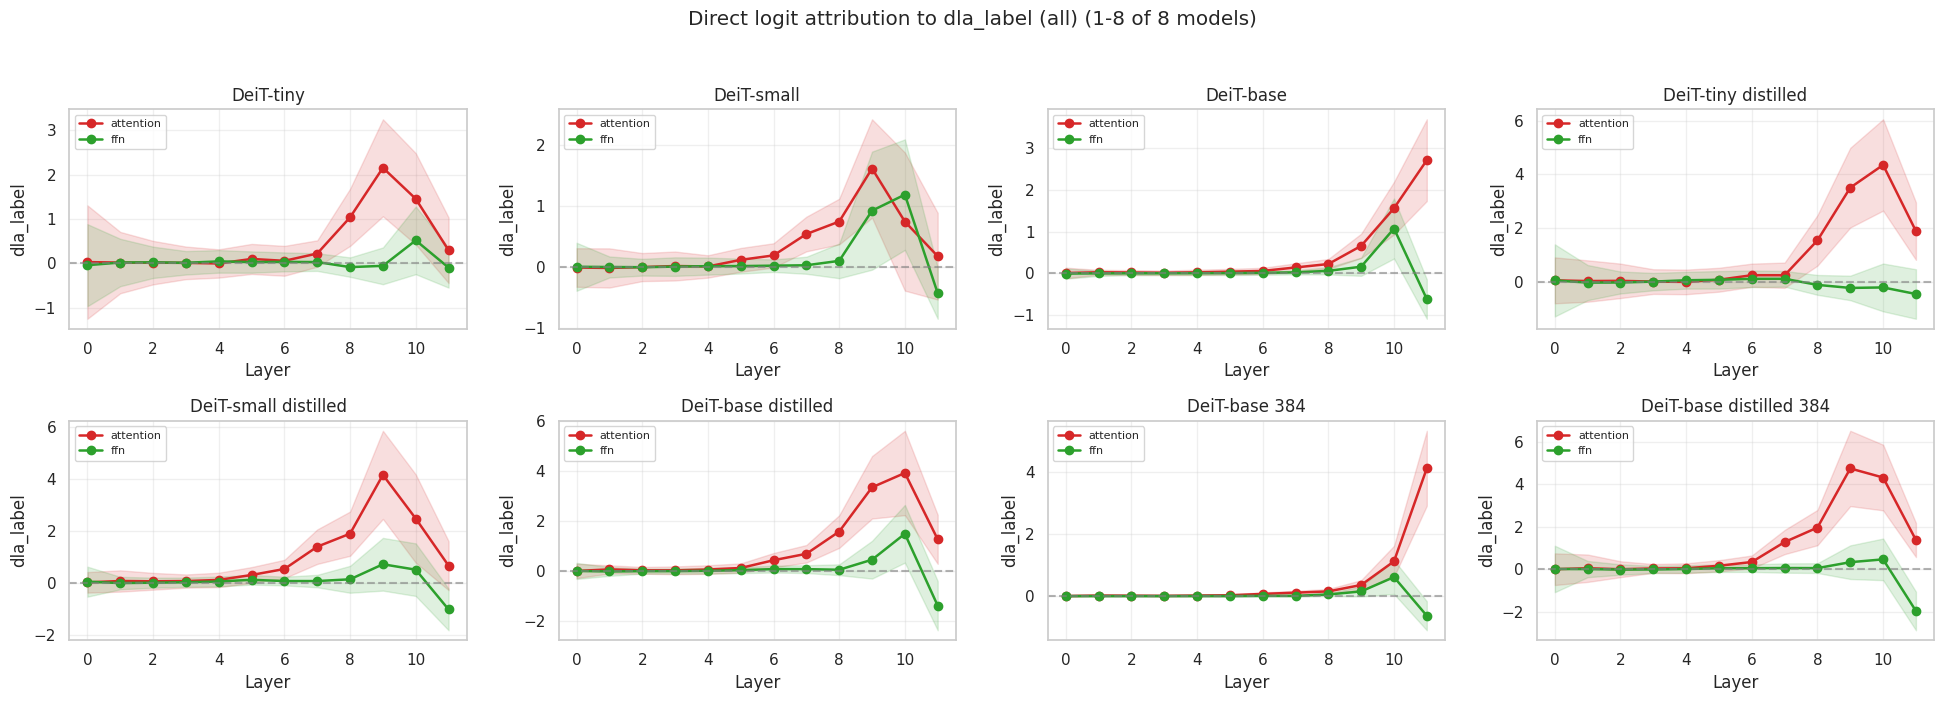

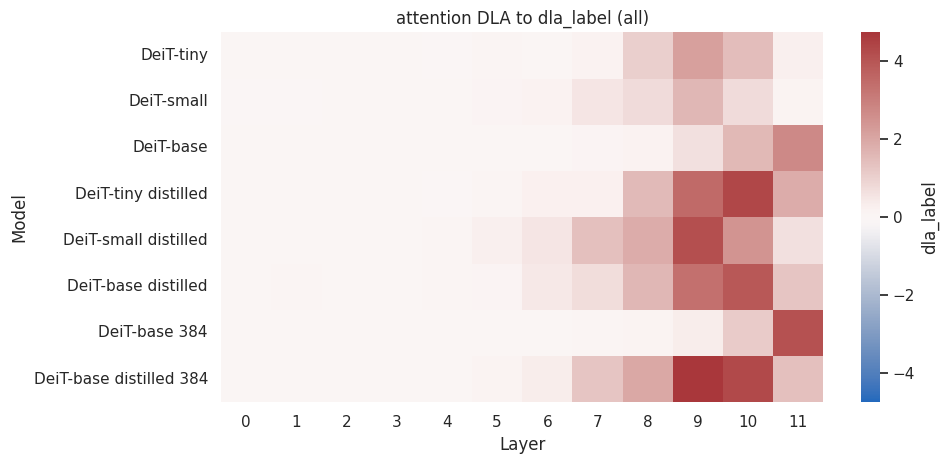

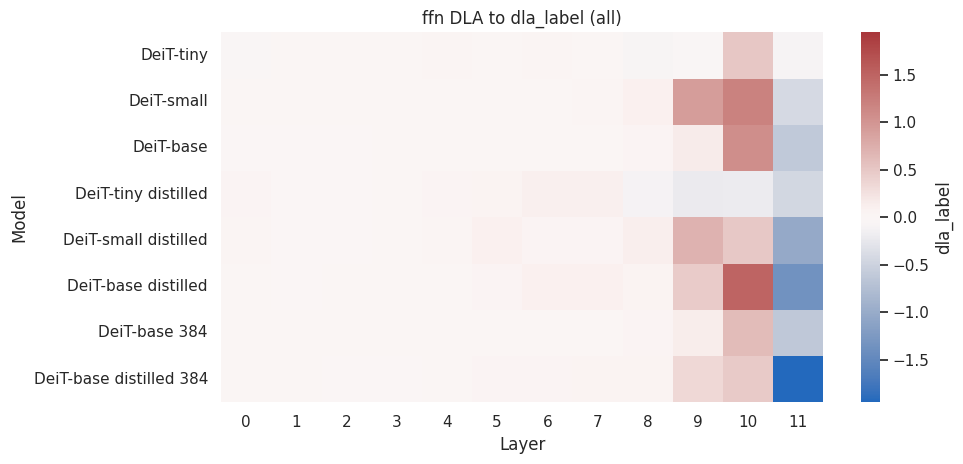

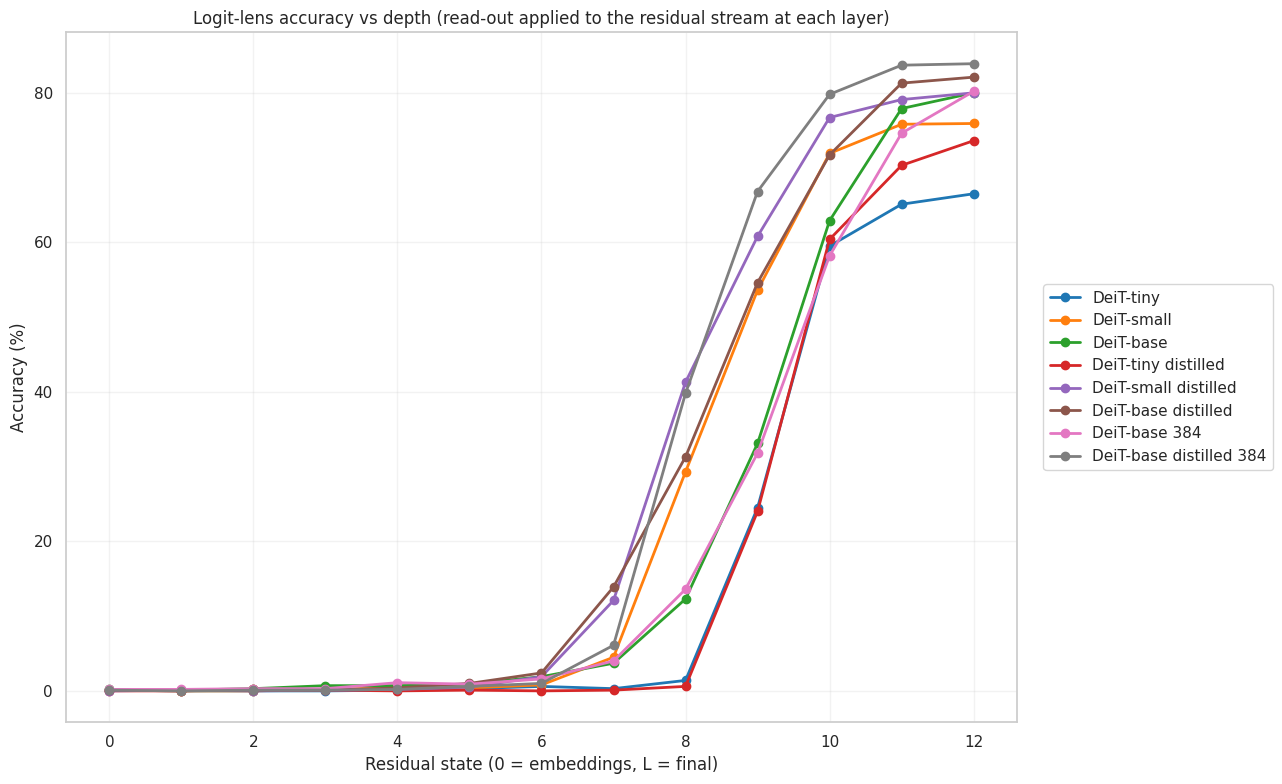

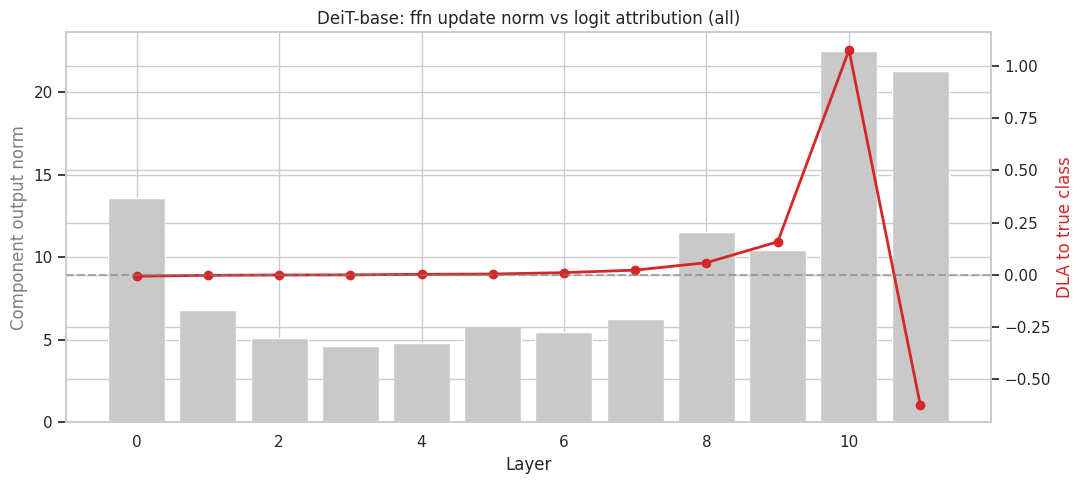

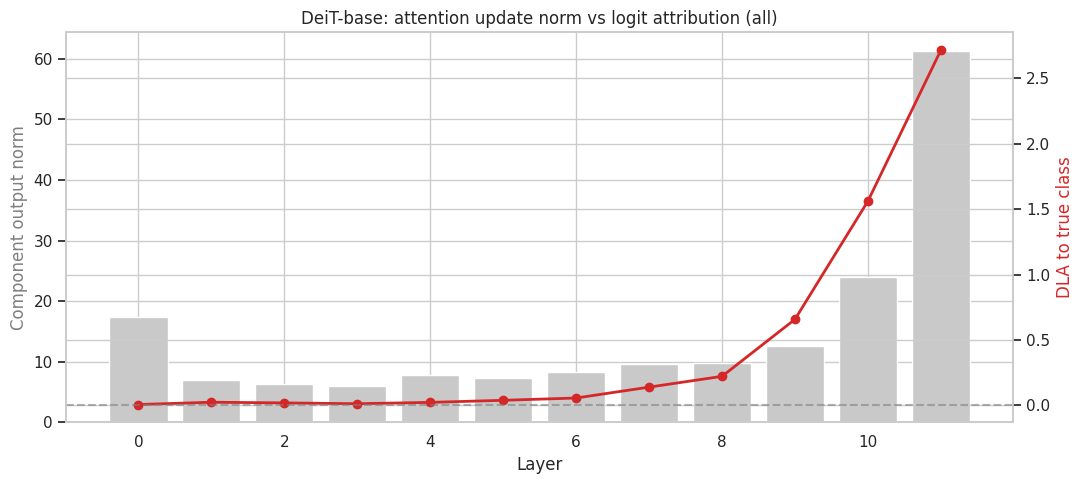

In [8]:
plot_dla_report(dla_summary_df, selected_specs, metric="dla_label", split="all")
plot_dla_heatmap(dla_summary_df, selected_specs, component="attention", metric="dla_label")
plot_dla_heatmap(dla_summary_df, selected_specs, component="ffn", metric="dla_label")
plot_logit_lens_comparison(logit_lens_df, selected_specs)
plot_dla_vs_norm(dla_summary_df, "DeiT-base", component="ffn")
plot_dla_vs_norm(dla_summary_df, "DeiT-base", component="attention")


In [9]:
results_dir = Path(EXPERIMENT_CONFIG["results_dir"])
dla_summary_df = pd.read_csv(results_dir / "dla_summary_all_models.csv")
logit_lens_df = pd.read_csv(results_dir / "logit_lens_all_models.csv")
dla_summary_df.head()


,model_name,repo_id,layer,component,metric,mean,std,count,split
0,DeiT-tiny,facebook/deit-tiny-patch16-224,0,attention,comp_norm,8.654464,0.124599,1000,all
1,DeiT-tiny,facebook/deit-tiny-patch16-224,0,attention,contrib_norm,40.526406,5.684475,1000,all
2,DeiT-tiny,facebook/deit-tiny-patch16-224,0,attention,dla_label,0.026044,1.280713,1000,all
3,DeiT-tiny,facebook/deit-tiny-patch16-224,0,attention,dla_pred,0.017411,1.281779,1000,all
4,DeiT-tiny,facebook/deit-tiny-patch16-224,0,ffn,comp_norm,6.153107,0.070865,1000,all
